# W3 kink harvest — QDB reference run (frozen config)

Engine-native reference run of `BT/signals/cvx_kink_harvest.py` on the shipped
signal panel `docs/cvxsuite/harvest_panel.parquet`. Episodes are multi-month
holds under monthly reform (the two extractor-verified episodes are ~3m and
~2m); the QDB grid is the union of the priced episode windows.

**FROZEN config (docs/cvxsuite/DESIGN.md §6 "Kink harvest" — run AS IS, ugly
numbers are the deliverable):** pairs {10y10y/15y10y, 10y10y/20y10y,
15y5y/20y10y}; gates `min_be_over_rv = 1.17`, `max_z = +0.5`,
`min_rac_net = 0.0` at the measured half-life horizon — the PAIR-shape
gates, where the level-long steepener IS the harvest side (distinct from
books.py's point-row fly gate, re-signed for the receive-belly side by §6a
item 5; nothing in THIS book's gates changed); monthly reform; lag-1
(every reform decision reads the t−1 panel row); package DV01 $100k; costs
at the §6-frozen 0.3bp/leg one-way (`half_spread_bp = 0.30`, restored by
§6a item 3 — the previously shipped 0.25 was a 16.7% understatement of
this section; fee `2 legs × 2 sides × 0.30bp × $100k = $120,000` per
closed round trip), reported at cost multiples {0, 0.5, 1, 2}× by
recosting the gross arithmetically. The two extractor-verified episodes
are UNCHANGED by §6a (the harvest gate columns were untouched); the
pre-fix run's $100,000 fee lines are superseded.

**What this notebook is allowed to claim:** engine-certified reference
numbers only — NO aliveness claims. Verdicts belong to the RV-loop ledger and
nothing here registers a family. Incumbent nulls, named (DESIGN §0):
F3 xsec fade median 63d reversion **+0.81…+1.14bp vs ≥1.0bp RT** (pond equals
boat); W4 rac harvest **gross 0.397 < null 0.446** (duration in disguise);
strat1 grid null **E[max SR | 5,040 cells] = 1.599**.

**Honesty rules:** an episode that cannot price (missing curve day at entry
or exit) is refused with a printed reason and the run continues; totals state
`n_priced/n_declared`. No parameter is tuned; the frozen config runs even if
the result is ugly.

In [1]:
import os

os.environ.setdefault("ARBS_SUPABASE_ENABLED", "0")  # BEFORE any repo import

import pathlib
import sys
import time

import matplotlib

if "ipykernel" not in sys.modules:
    matplotlib.use("Agg")  # headless guard: plain-python runs never open a GUI

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

_REPO = (pathlib.Path(__file__).resolve().parents[3] if "__file__" in dir()
         else pathlib.Path.cwd().parents[2])
sys.path.insert(0, str(_REPO))

from BT.signals.cvx_kink_harvest import (
    KinkHarvestConfig,
    episodes_from_panel,
    run_backtest,
)
from BT.signals.cvx_strikeless import CurveMapMDP, build_curve_map

PANEL_PATH = _REPO / "docs" / "cvxsuite" / "harvest_panel.parquet"
CFG = KinkHarvestConfig()  # the frozen §6 config — every field at its default
print("frozen config:", CFG)

frozen config: KinkHarvestConfig(pairs=('10y10y/15y10y', '10y10y/20y10y', '15y5y/20y10y'), min_be_over_rv=1.17, max_z=0.5, min_rac_net=0.0, reform='M', package_dv01_usd=100000.0, half_spread_bp=0.3, start=datetime.date(2019, 1, 2), end=datetime.date(2026, 8, 25))


## 1. Panel → episodes (the extractor-verified count is pinned)

The shipped panel is the signal layer (int1_1 build: 5,736 rows, 3 pairs,
2019-01-02..2026-08-24). The extractor was verified on this exact parquet to
produce **2 episodes** (10y10y/15y10y 2023-07-03→2023-10-02 and
2024-12-02→2025-02-03); the assert below pins that — a different count means
the panel or extractor drifted and this notebook must fail loudly rather
than quietly grade a different book.

In [2]:
panel = pd.read_parquet(PANEL_PATH)
print(f"panel: {panel.shape}, index {panel.index.names}, "
      f"{panel.index.get_level_values('date').min().date()}"
      f"..{panel.index.get_level_values('date').max().date()}")

episodes = episodes_from_panel(panel, CFG)
for e in episodes:
    print(f"  episode {e.pair}  {e.entry_date.date()} -> {e.exit_date.date()}")
assert len(episodes) == 2, (
    f"expected the 2 extractor-verified episodes on the shipped panel, got "
    f"{len(episodes)} — panel or extractor drifted")

panel: (5736, 10), index ['date', 'pair'], 2019-01-02..2026-08-24
  episode 10y10y/15y10y  2023-07-03 -> 2023-10-02
  episode 10y10y/15y10y  2024-12-02 -> 2025-02-03


## 2. Offline curve map over the union of episode windows

`build_curve_map` (the cvx_strikeless guard set: offline-only, refuses
today, drops reference-date-mismatched holiday rows loudly, asserts
`from_curve_store`). An episode whose entry or exit day the store cannot
serve is REFUSED and printed — never date-shifted. The grid is the served
days inside the PRICED episodes' windows only.

In [3]:
dates_all = panel.index.get_level_values("date").unique().sort_values()
declared = list(episodes)
union_declared = sorted({d for e in declared for d in dates_all
                         if e.entry_date <= d <= e.exit_date})
print(f"union of declared windows: {len(union_declared)} panel days")

t0 = time.time()
curve_map = build_curve_map(union_declared, n_jobs=1)
print(f"curve map: {len(curve_map)} served days in {time.time() - t0:.0f}s")

priced = []
for e in declared:
    missing = [d.date() for d in (e.entry_date, e.exit_date)
               if pd.Timestamp(d).date() not in curve_map]
    if missing:
        print(f"REFUSED {e.pair} {e.entry_date.date()}->{e.exit_date.date()}: "
              f"no curve for {missing} — episode cannot price")
        continue
    priced.append(e)
print(f"episodes priced: n_priced/n_declared = {len(priced)}/{len(declared)}")

grid = sorted(d for d in curve_map
              if any(e.entry_date.date() <= d <= e.exit_date.date() for e in priced))
print(f"grid: {len(grid)} served days inside priced windows "
      f"({grid[0]}..{grid[-1]})")

union of declared windows: 107 panel days


C:\Users\chris\clee\ARBS-cvxsuite\MDP\CitiVelocityExcel\curves\rl_builder.py:79: LicenceNotice: 
Rateslib is source-available (not open-source) software distributed under a dual-licence model.
No commercial licence is registered for this installation. Use is therefore permitted for non-commercial purposes only (at-home or university based academic use).
Any use in commercial, professional, or for-profit environments, including evaluation or trial use, requires a valid commercial licence or an approved evaluation licence.
Certain features may require a registered commercial or evaluation licence in current or future versions.
For licensing information or to register a licence, please visit: https://rateslib.com/licence
  import rateslib as rl


curve map: 107 served days in 3s
episodes priced: n_priced/n_declared = 2/2
grid: 107 served days inside priced windows (2023-07-03..2025-02-03)


## 3. The engine run

`run_backtest` = build (explicit effective/maturity resolved on the entry
curve, per-episode tags, plain-`date` triggers) → ±bpv sign probe on the
first episode's front leg → run → `assert_ran` battery. Marks are served
from `CurveMapMDP` — a closed dict of the pre-fetched store pricers with no
fetch path at all (the strongest offline form).

In [4]:
serving = CurveMapMDP(curve_map, curve_name="USD-SOFR-1D")
t0 = time.time()
bt, equity_raw = run_backtest(priced, grid, serving, cfg=CFG, probe=True,
                              show_progress=False)
print(f"engine run: {len(bt.mtm_history)} marks in {time.time() - t0:.0f}s")

C:\Users\chris\anaconda3\envs\stir\Lib\site-packages\rateslib\data\fixings.py:3426: RuntimeWarning: invalid value encountered in divide
  r = (v[:-1] / v[1:] - 1) * 100 / dcfs_obs[len(populated) :]


engine run: 107 marks in 3s


## 4. Mandatory run-artifact asserts

`QueryDrivenBacktest.run()` swallows per-step exceptions, so the artifacts
are the only evidence the run happened.

In [5]:
assert bt.mtm_history, "engine produced no marks — run() swallows exceptions"
equity = pd.Series(bt.mtm_history).sort_index()
n_nonzero = int((equity.abs() > 1e-9).sum())
print(f"non-zero marks: {n_nonzero} of {len(equity)}")
assert n_nonzero > 0, "equity identically zero — no trigger ever fired"

closed = pd.DataFrame(list(bt.portfolio.closed_positions_log))
n_expected_legs = 2 * len(priced)  # 2 OUTRIGHT legs per episode
print(f"closed positions: {len(closed)} (expected {n_expected_legs})")
assert len(closed) == n_expected_legs, (
    f"closed {len(closed)} legs, expected {n_expected_legs} — an unwind missed "
    "its tag or an add never filled")
assert len(equity) == len(grid), "equity-curve holes: engine swallowed steps"

non-zero marks: 106 of 107
closed positions: 4 (expected 4)


## 5. Per-episode gross/net/fees, and cost multiples by recosting

The engine books the fee once per episode at its unwind
(`2 legs × 2 sides × 0.30bp × $100k = $120,000` per closed round trip — the
§6a item-3 restored constant; the previously shipped 0.25/$100,000
understated the frozen §6 band by 16.7%). Gross is the engine-repriced
P&L with the fee added back.
Cost multiples {0, 0.5, 1, 2}× recompute net **arithmetically** from the
gross (`net_m = gross − m × fee_1x`); the engine is NOT re-run per multiple.

In [6]:
FEE_1X = 2.0 * 2.0 * CFG.half_spread_bp * CFG.package_dv01_usd
closed["tag"] = closed["position_meta"].map(lambda m: (m or {}).get("tags", ["?"])[0])
rows = []
for k, e in enumerate(priced):
    legs = closed[closed["tag"] == f"kh{k}"]
    assert len(legs) == 2, f"episode kh{k}: expected 2 closed legs, got {len(legs)}"
    gross = float(legs["gross_realized_pnl"].sum())
    fee = float(legs["fee_allocated"].sum())
    assert abs(fee - FEE_1X) < 1e-6, f"episode kh{k}: fee {fee} != {FEE_1X}"
    hold_bd = int(sum(1 for d in grid
                      if e.entry_date.date() <= d <= e.exit_date.date()) - 1)
    rows.append({"episode": f"kh{k}", "pair": e.pair,
                 "entry": e.entry_date.date(), "exit": e.exit_date.date(),
                 "hold_bd": hold_bd, "gross_usd": gross, "fee_1x_usd": fee,
                 "net_usd_1x": gross - fee,
                 "gross_bp": gross / CFG.package_dv01_usd,
                 "net_bp_1x": (gross - fee) / CFG.package_dv01_usd})
ep = pd.DataFrame(rows)
print(ep.to_string(index=False))

gross_total = float(ep["gross_usd"].sum())
fee_total_1x = float(ep["fee_1x_usd"].sum())
print(f"\nTOTALS over n_priced/n_declared = {len(priced)}/{len(declared)} episodes:"
      f"\n  gross {gross_total:+,.0f} USD ({gross_total / CFG.package_dv01_usd:+.2f}bp"
      f" of package DV01), fees@1x {fee_total_1x:,.0f} USD")
for m in (0.0, 0.5, 1.0, 2.0):
    net_m = gross_total - m * fee_total_1x
    print(f"  net @ {m:>3}x cost = {net_m:+,.0f} USD "
          f"({net_m / CFG.package_dv01_usd:+.2f}bp)")

net_engine = float(equity.iloc[-1])
assert abs(net_engine - (gross_total - fee_total_1x)) < 1.0, (
    f"engine terminal net {net_engine:,.2f} != gross - 1x fees "
    f"{gross_total - fee_total_1x:,.2f}")
print(f"  engine terminal equity (net@1x) {net_engine:+,.0f} USD — ties out")

episode          pair      entry       exit  hold_bd      gross_usd  fee_1x_usd    net_usd_1x  gross_bp  net_bp_1x
    kh0 10y10y/15y10y 2023-07-03 2023-10-02       63 -945369.699228    120000.0 -1.065370e+06 -9.453697 -10.653697
    kh1 10y10y/15y10y 2024-12-02 2025-02-03       42 -113138.132185    120000.0 -2.331381e+05 -1.131381  -2.331381

TOTALS over n_priced/n_declared = 2/2 episodes:
  gross -1,058,508 USD (-10.59bp of package DV01), fees@1x 240,000 USD
  net @ 0.0x cost = -1,058,508 USD (-10.59bp)
  net @ 0.5x cost = -1,178,508 USD (-11.79bp)
  net @ 1.0x cost = -1,298,508 USD (-12.99bp)
  net @ 2.0x cost = -1,538,508 USD (-15.39bp)
  engine terminal equity (net@1x) -1,298,508 USD — ties out


## 6. Equity path — Sharpe, NW t-stat, max drawdown, step plot

Marks exist only on held-window days (the grid), so the annualised Sharpe is
a reference number on marked days. `mtm_history` is NET of fees, and fees
land as lumps at unwinds (the engine's only cost hook) — the net daily path
inside an episode is gross until its unwind day, so the gross-daily Sharpe
is printed alongside (c23_0 risk note: never read a smooth net path off
mtm diffs).

net@1x:  ann. Sharpe (marked days) -2.27, NW t -1.39, maxDD -1,706,607 USD
gross:   ann. Sharpe (marked days) -1.93, NW t -1.16
(fee timing: lumps at unwinds — net Sharpe carries the unwind-day spikes)


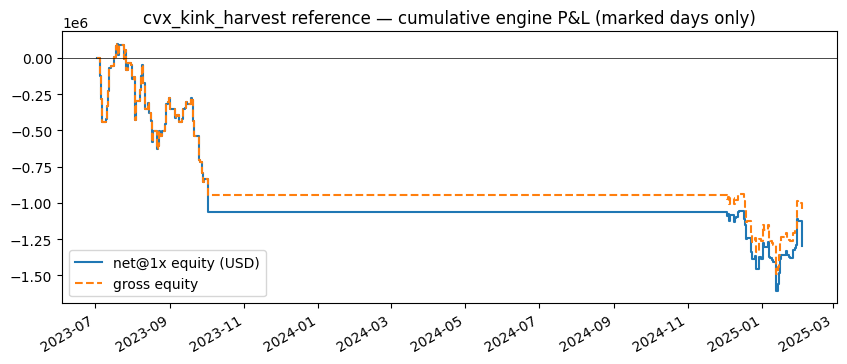

In [7]:
from RVUtils.SFRRVLab.stats import nw_tstat

daily_net = equity.diff()
daily_net.iloc[0] = equity.iloc[0]
fees_by_day = closed.groupby(closed["closed_at"].map(pd.Timestamp))["fee_allocated"].sum()
daily_gross = daily_net.add(fees_by_day.reindex(daily_net.index).fillna(0.0))

def _sr(x: pd.Series) -> float:
    sd = float(x.std(ddof=1))
    return float("nan") if sd == 0 else float(x.mean() / sd * np.sqrt(252.0))

dd = equity - equity.cummax()
print(f"net@1x:  ann. Sharpe (marked days) {_sr(daily_net):+.2f}, "
      f"NW t {nw_tstat(daily_net):+.2f}, maxDD {dd.min():,.0f} USD")
print(f"gross:   ann. Sharpe (marked days) {_sr(daily_gross):+.2f}, "
      f"NW t {nw_tstat(daily_gross):+.2f}")
print("(fee timing: lumps at unwinds — net Sharpe carries the unwind-day spikes)")

fig, ax = plt.subplots(figsize=(10, 4))
ax.step(equity.index, equity.values, where="post", label="net@1x equity (USD)")
ax.step(equity.index, equity.values + fees_by_day.reindex(equity.index)
        .fillna(0.0).cumsum().values, where="post", ls="--", label="gross equity")
ax.axhline(0, lw=0.5, color="k")
ax.set_title("cvx_kink_harvest reference — cumulative engine P&L (marked days only)")
ax.legend()
fig.autofmt_xdate()
plt.show()

## 7. Closed-positions log

In [8]:
view = closed[["tag", "opened_at", "closed_at", "holding_period_steps",
               "gross_realized_pnl", "fee_allocated", "realized_pnl"]].copy()
print(view.to_string(index=False))
print(f"\nfee_allocated sums to {closed['fee_allocated'].sum():,.0f} USD "
      f"(= {len(priced)} x {FEE_1X:,.0f})")

tag  opened_at  closed_at  holding_period_steps  gross_realized_pnl  fee_allocated  realized_pnl
kh0 2023-07-03 2023-10-02                    63       -8.798179e+06        60000.0 -8.858179e+06
kh0 2023-07-03 2023-10-02                    63        7.852810e+06        60000.0  7.792810e+06
kh1 2024-12-02 2025-02-03                    42       -3.957767e+06        60000.0 -4.017767e+06
kh1 2024-12-02 2025-02-03                    42        3.844629e+06        60000.0  3.784629e+06

fee_allocated sums to 240,000 USD (= 2 x 120,000)


## 8. Tearsheet (plain-stats fallback if plotting is unavailable)

In [9]:
try:
    from IPython.display import display

    from BT.query_tearsheet import QueryBacktestTearSheet

    ts = QueryBacktestTearSheet.from_backtest(bt)
    display(ts.plot_plotly())
except Exception as exc:  # noqa: BLE001 — fallback is the contract
    print(f"tearsheet unavailable ({type(exc).__name__}: {exc}); plain stats:")
    print(f"  marks {len(equity)}, net {equity.iloc[-1]:+,.0f} USD, "
          f"gross {gross_total:+,.0f} USD, fees@1x {fee_total_1x:,.0f} USD, "
          f"episodes {len(priced)}, closed legs {len(closed)}, maxDD {dd.min():,.0f} USD")

## 9. DSR at the declared suite config count

`n_trials = 4` — the declared §6 cell count across the whole suite (2
strikeless pairs + 1 harvest + 1 dislocation config). This notebook runs ONE
frozen cell, so there is no cross-trial Sharpe dispersion to measure here;
`sr_variance=None` makes the benchmark `sr0 = 0` and the DSR reduces to
PSR(SR > 0) — the n_trials=4 deflation is therefore NOT active in this
number, and that is printed rather than hidden.

In [10]:
from BT.signals.deflated_sharpe import deflated_sharpe

d = deflated_sharpe(daily_net.to_numpy(dtype=float), n_trials=4, sr_variance=None)
print(f"DSR on daily net P&L: dsr_prob {d['dsr_prob']:.3f}  (sr {d['sr']:+.4f}/day, "
      f"annualised {d['sr_annualised']:+.2f}, sr0 {d['sr0']:.4f} — sr0=0 because a "
      f"single frozen cell has no cross-trial dispersion; DSR here = PSR vs 0)")
print("reference number at the declared config count, not a verdict")

DSR on daily net P&L: dsr_prob 0.063  (sr -0.1429/day, annualised -2.27, sr0 0.0000 — sr0=0 because a single frozen cell has no cross-trial dispersion; DSR here = PSR vs 0)
reference number at the declared config count, not a verdict


## 10. What this run certifies — and does not

Certifies: the frozen §6 harvest book is expressible in the production
engine — panel gates → episodes → real `AddQueryAction`/
`UnwindPositionsAction` events on explicit-dated OUTRIGHT legs, sign
convention re-derived from the engine, no equity-curve holes, fee totals
exactly the known constants. Does NOT certify a strategy: no aliveness
claim, no RV-loop registration, no verdict. The incumbent nulls in the
header are the bar any future claim would have to clear.